In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [95]:
df = pd.read_csv("datasets/titanic.csv")

In [111]:
df.shape

(891, 12)

In [98]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [104]:
df.columns[df.isna().sum() > 0]

Index(['Age', 'Cabin', 'Embarked'], dtype='object')

In [ ]:
df.columns[(df.dtypes == int) | (df.dtypes == float)]

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

In [114]:
df.columns[df.dtypes == object]

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [125]:
df[['Name', 'Age', 'Sex']]

,Name,Age,Sex
0,"Braund, Mr. Owen Harris",22.0,male
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female
2,"Heikkinen, Miss. Laina",26.0,female
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female
4,"Allen, Mr. William Henry",35.0,male
...,...,...,...
886,"Montvila, Rev. Juozas",27.0,male
887,"Graham, Miss. Margaret Edith",19.0,female
888,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,female
889,"Behr, Mr. Karl Howell",26.0,male


In [127]:
df.iloc[0:10]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [129]:
df[df["Age"] > 60].head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
54,55,0,1,"Ostby, Mr. Engelhart Cornelius",male,65.0,0,1,113509,61.9792,B30,C
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
170,171,0,1,"Van der hoef, Mr. Wyckoff",male,61.0,0,0,111240,33.5000,B19,S


In [130]:
print(df["Age"].mean())
print(df["Age"].median())
print(df["Age"].min())
print(df["Age"].max())

29.69911764705882
28.0
0.42
80.0


In [141]:
df[["Name", "Fare"]][df["Fare"] > 100].head()

,Name,Fare
27,"Fortune, Mr. Charles Alexander",263.0000
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",146.5208
88,"Fortune, Miss. Mabel Helen",263.0000
118,"Baxter, Mr. Quigg Edmond",247.5208
195,"Lurette, Miss. Elise",146.5208


In [142]:
df["Name"][(df["Survived"] == 1) & (df["Sex"] == "female")].head()

1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: object

In [143]:
df[["Name", "Age", "Sex"]][(df["Sex"] == "male") | (df["Age"] < 18)]

,Name,Age,Sex
0,"Braund, Mr. Owen Harris",22.0,male
4,"Allen, Mr. William Henry",35.0,male
5,"Moran, Mr. James",NaN,male
6,"McCarthy, Mr. Timothy J",54.0,male
7,"Palsson, Master. Gosta Leonard",2.0,male
...,...,...,...
883,"Banfield, Mr. Frederick James",28.0,male
884,"Sutehall, Mr. Henry Jr",25.0,male
886,"Montvila, Rev. Juozas",27.0,male
889,"Behr, Mr. Karl Howell",26.0,male


In [145]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [148]:
df.groupby("Pclass")["Age"].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

In [162]:
df.groupby("Pclass")["Pclass"].count()

Pclass
1    216
2    184
3    491
Name: Pclass, dtype: int64

In [ ]:
class_1_survived = np.array(df[(df["Pclass"] == 1)]["Survived"])
class_2_survived = np.array(df[(df["Pclass"] == 2)]["Survived"])
class_3_survived = np.array(df[(df["Pclass"] == 3)]["Survived"])

class_1_surv_rate = class_1_survived[class_1_survived == 1].size / class_1_survived.size
class_2_surv_rate = class_2_survived[class_2_survived == 1].size / class_2_survived.size
class_3_surv_rate = class_3_survived[class_3_survived == 1].size / class_3_survived.size

np.array([class_1_surv_rate, class_2_surv_rate, class_3_surv_rate])

# Couldn't think of a better way to do this sorry

array([0.62962963, 0.47282609, 0.24236253])

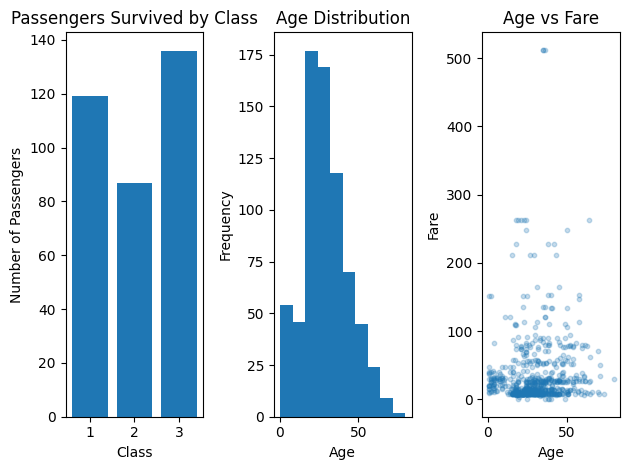

In [200]:
fig, ax = plt.subplots(1, 3)

survived_per_class = df[df["Survived"] == 1]["Pclass"].value_counts().to_numpy()
ax[0].bar(df["Pclass"].unique(), survived_per_class)
ax[0].set_title("Passengers Survived by Class")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Number of Passengers")

ax[1].hist(df["Age"].dropna())
ax[1].set_title("Age Distribution")
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Frequency")

ax[2].scatter(df["Age"], df["Fare"], alpha=0.25, s=10)
ax[2].set_title("Age vs Fare")
ax[2].set_xlabel("Age")
ax[2].set_ylabel("Fare")

plt.tight_layout()
plt.show()